In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection import _utils
from torchvision.models.detection import SSD300_VGG16_Weights
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm  

import sys, os
sys.path.append(os.path.abspath('..'))
from CustomDataset import CustomDataset
from proposal_codes.transform import transforms_with_boxes, val_transforms
from proposal_codes.utils import show_img_with_boxes, to_device
from EarlyStopping import EarlyStopping

In [2]:
## TRAIN DATALOADER
train_image_dir = "../data/incabinDetection/train/images"
train_annotation_dir = "../data/incabinDetection/train/labels"
train_annotations = os.listdir(train_annotation_dir)

train_dataset = CustomDataset(train_image_dir, 
                              train_annotations, 
                              train_annotation_dir, 
                              transform=transforms_with_boxes)

train_data_loader = DataLoader(train_dataset, 
                               batch_size=4, 
                               shuffle=True, 
                               collate_fn=lambda x: tuple(zip(*x)))

# VAL DATALOADER
val_image_dir = "../data/incabinDetection/valid/images"
val_annotation_dir = "../data/incabinDetection/valid/labels"
val_annotations = os.listdir(val_annotation_dir)

val_dataset = CustomDataset(val_image_dir, 
                              val_annotations, 
                              val_annotation_dir, 
                              transform=val_transforms)

val_data_loader = DataLoader(val_dataset, 
                               batch_size=4, 
                               shuffle=False, 
                               collate_fn=lambda x: tuple(zip(*x)))


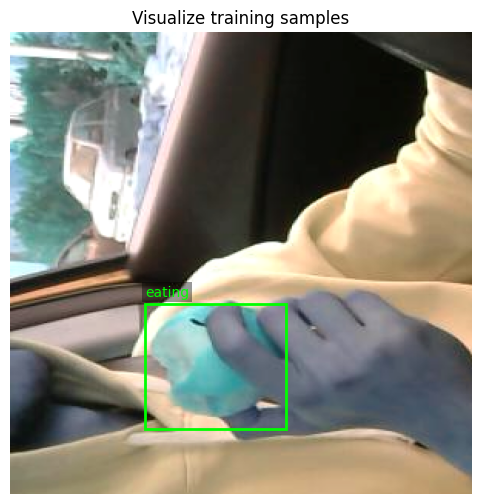

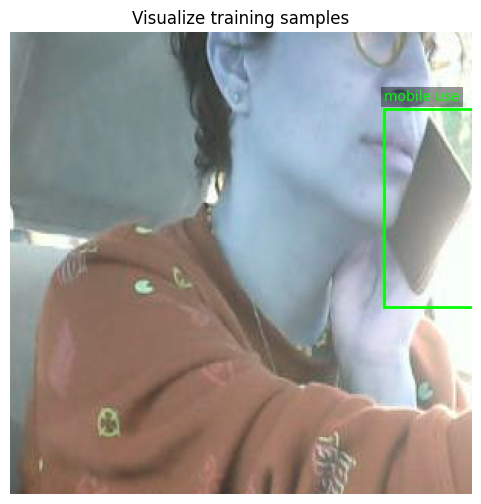

In [4]:
sample_iter = iter(train_data_loader)
label_names = {
    1:'drinking',
    2:'eating',
    3: 'mobile use',
    4: 'smoking'}

for _ in range(2):
    sample = next(sample_iter)
    img, target = sample
    show_img_with_boxes(img[0], target[0], label_names=label_names, title="Visualize training samples")


In [10]:
def create_model(num_classes=4, size=300):
    model = torchvision.models.detection.ssd300_vgg16(weights=SSD300_VGG16_Weights.COCO_V1)

    in_channels = _utils.retrieve_out_channels(model.backbone, (size, size))
    num_anchors = model.anchor_generator.num_anchors_per_location()

    # Replace the classification head for 4 classes + background
    model.head.classification_head = SSDClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes + 1
    )

    # Adjust transform sizes
    model.transform.min_size = (size,)
    model.transform.max_size = size

    for param in model.backbone.parameters():
        param.requires_grad = True

    return model

model = create_model(num_classes=4, size=300)
print(model)


Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /home/kien/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:01<00:00, 108MB/s]  


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [11]:
# Training Setup
num_epochs = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
metric = MeanAveragePrecision().to(device)
early_stopper = EarlyStopping(patience=7, min_delta=1e-4, mode="max")

print("trainable:" , len(params))

trainable: 71


In [ ]:
history = {
    "train_loss": [],      
    "val_map": [],
    "val_map_50": [],
    "loss_classifier": [],
    "loss_box_reg": [],
    "val_loss": [],
    "val_loss_classifier": [],
    "val_loss_box_reg": []

}

for epoch in range(num_epochs):
    
    model.train()
    
    running_loss = 0.0
    running_cls_loss = 0.0
    running_box_loss = 0.0
    
    # Create progress bar
    train_loop = tqdm(enumerate(train_data_loader), total=len(train_data_loader), leave=True)
    train_loop.set_description(f"Epoch {epoch+1}/{num_epochs} [Train]")

    for i, (images, targets) in train_loop:
        images = to_device(images)
        targets = to_device(targets)

        # Fix 1D boxes
        for t in targets:
            if t["boxes"].ndim == 1: 
                t["boxes"] = t["boxes"].view(-1, 4)

        # Forward pass
        loss_dict = model(images, targets)
        
        # Calculate total loss
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        # Tracking Metrics
        loss_value = losses.item()
        running_loss += loss_value
        
        # Track specific losses
        cls_loss = loss_dict['loss_classifier'].item() if 'loss_classifier' in loss_dict else 0
        box_loss = loss_dict['loss_box_reg'].item() if 'loss_box_reg' in loss_dict else 0
        
        running_cls_loss += cls_loss
        running_box_loss += box_loss

        # Update progress bar with current batch loss
        train_loop.set_postfix(loss=loss_value, cls=cls_loss, box=box_loss)

    # Step LR Scheduler
    if scheduler:
        scheduler.step()

    # Calculate average losses for the epoch
    avg_train_loss = running_loss / len(train_data_loader)
    avg_cls_loss = running_cls_loss / len(train_data_loader)
    avg_box_loss = running_box_loss / len(train_data_loader)

    history["train_loss"].append(avg_train_loss)
    history["loss_classifier"].append(avg_cls_loss)
    history["loss_box_reg"].append(avg_box_loss)

    # VALIDATION PHASE
    metric.reset()

    val_running_loss = 0.0
    val_running_cls_loss = 0.0  
    val_running_box_loss = 0.0
    
    # Create progress bar
    val_loop = tqdm(enumerate(val_data_loader), total=len(val_data_loader), leave=True)
    val_loop.set_description(f"Epoch {epoch+1}/{num_epochs} [Valid]")

    with torch.no_grad():
        for i, (vinputs, vlabels) in val_loop:
            vinputs = to_device(vinputs)
            vlabels = to_device(vlabels)

            # Fix 1D boxes if necessary (same as train)
            for t in vlabels:
                if t["boxes"].ndim == 1:
                    t["boxes"] = t["boxes"].view(-1, 4)

            # 1) Compute validation loss (TorchVision detection models want train() for losses)
            model.train()
            val_loss_dict = model(vinputs, vlabels)
            val_losses = sum(loss for loss in val_loss_dict.values())

            loss_value = val_losses.item()
            val_running_loss += loss_value

            val_cls = val_loss_dict["loss_classifier"].item() if "loss_classifier" in val_loss_dict else 0.0
            val_box = val_loss_dict["loss_box_reg"].item() if "loss_box_reg" in val_loss_dict else 0.0
            val_running_cls_loss += val_cls
            val_running_box_loss += val_box

            # Compute predictions for mAP
            model.eval()
            voutputs = model(vinputs)
            metric.update(voutputs, vlabels)

            val_loop.set_postfix(vloss=loss_value, vcls=val_cls, vbox=val_box)
    
    # Average val losses
    avg_8574val_loss = val_running_loss / len(val_data_loader)
    avg_val_cls_loss = val_running_cls_loss / len(val_data_loader)
    avg_val_box_loss = val_running_box_loss / len(val_data_loader)

    history["val_loss"].append(avg_val_loss)
    history["val_loss_classifier"].append(avg_val_cls_loss)
    history["val_loss_box_reg"].append(avg_val_box_loss)

    # Compute Metrics
    metric_results = metric.compute()
    val_map = metric_results['map'].item()
    val_map_50 = metric_results['map_50'].item()
    
    history["val_map"].append(val_map)
    history["val_map_50"].append(val_map_50)

    # EARLY STOPPING CHECK
    if early_stopper.step(val_map_50, model, epoch):
        print(f"Early stopping triggered at epoch {epoch+1}. Best epoch: {early_stopper.best_epoch+1} "
              f"with val mAP={early_stopper.best:.4f}")
        break

    # --- FINAL EPOCH LOGGING ---
    print(f"\nSummary Epoch {epoch+1}:")
    print(f"Train Loss: {avg_train_loss:.4f} | Cls Loss: {avg_cls_loss:.4f} | Box Reg: {avg_box_loss:.4f}")
    print(f"Val   Loss: {avg_val_loss:.4f} | Cls Loss: {avg_val_cls_loss:.4f} | Box Reg: {avg_val_box_loss:.4f}")
    print(f"Val mAP:    {val_map:.4f}       | Val mAP50: {val_map_50:.4f}")
    print("-" * 60)

Epoch 1/50 [Valid]:   0%|          | 0/131 [00:00<?, ?it/s]/home/kien/torch_cuda/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
Epoch 1/50 [Valid]: 100%|██████████| 131/131 [00:09<00:00, 13.93it/s, vbox=0, vcls=0, vloss=7.05]



Summary Epoch 1:
Train Loss: 6.0968 | Cls Loss: 0.0000 | Box Reg: 0.0000
Val   Loss: 5.5084 | Cls Loss: 0.0000 | Box Reg: 0.0000
Val mAP:    0.0128       | Val mAP50: 0.0303
------------------------------------------------------------


Epoch 2/50 [Valid]: 100%|██████████| 131/131 [00:07<00:00, 16.56it/s, vbox=0, vcls=0, vloss=5.53]



Summary Epoch 2:
Train Loss: 5.4033 | Cls Loss: 0.0000 | Box Reg: 0.0000
Val   Loss: 4.9296 | Cls Loss: 0.0000 | Box Reg: 0.0000
Val mAP:    0.0611       | Val mAP50: 0.1533
------------------------------------------------------------


Epoch 3/50 [Valid]: 100%|██████████| 131/131 [00:07<00:00, 16.52it/s, vbox=0, vcls=0, vloss=5.76]


...


Summary Epoch 18:
Train Loss: 2.7494 | Cls Loss: 0.0000 | Box Reg: 0.0000
Val   Loss: 2.7536 | Cls Loss: 0.0000 | Box Reg: 0.0000
Val mAP:    0.4213       | Val mAP50: 0.8076
------------------------------------------------------------


Epoch 19/50 [Valid]: 100%|██████████| 131/131 [00:07<00:00, 16.75it/s, vbox=0, vcls=0, vloss=3.14]



Summary Epoch 19:
Train Loss: 2.7612 | Cls Loss: 0.0000 | Box Reg: 0.0000
Val   Loss: 2.6212 | Cls Loss: 0.0000 | Box Reg: 0.0000
Val mAP:    0.4226       | Val mAP50: 0.8083
------------------------------------------------------------


Epoch 20/50 [Valid]: 100%|██████████| 131/131 [00:09<00:00, 13.90it/s, vbox=0, vcls=0, vloss=1.69]


Early stopping triggered at epoch 20. Best epoch: 13 with val mAP=0.8304


In [13]:
torch.save(model.state_dict(), "SSD_mobile_detection.pth")